# Load Libraries and set global variables

In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timesfm

import warnings
warnings.filterwarnings("ignore")

TIME_COL = "Date"
TARGET = "price_mm20"
FORECAST_HORIZON = 10  # business days (~1 month)
FREQ = "B"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Simulate Financial Data

In [12]:
np.random.seed(12)

n     = 300  # business days (~15 months)
dates = pd.date_range(start="2022-01-01", periods=n, freq="B")

# Global dynamic covariates (same for all assets)
market_returns      = np.random.normal(0.0003, 0.015, n)
market_prices       = 1000 * np.exp(np.cumsum(market_returns))
market_mm20_series  = pd.Series(market_prices).rolling(20).mean().values

interest_rate_series = 0.05 + np.cumsum(np.random.normal(0, 0.00015, n))
interest_rate_series = np.clip(interest_rate_series, 0.01, 0.15)

vix_series = 20 + np.cumsum(np.random.normal(0, 0.08, n))
vix_series = np.clip(vix_series, 10, 80)

# Simulate 16 assets with 4 static covariates
sectors   = ["Tech", "Finance"]
caps      = ["Large", "Small"]
regions   = ["Dom", "Intl"]
asset_ids = ["A", "B"]

records = []
for sector in sectors:
    for cap in caps:
        for region in regions:
            for asset_id in asset_ids:
                drift      = np.random.uniform(0.0005, 0.002)
                volatility = np.random.uniform(0.02, 0.04)
                beta       = np.random.uniform(0.5, 1.5)

                idio_returns  = np.random.normal(drift, volatility, n)
                stock_returns = beta * market_returns + idio_returns

                price0 = np.random.uniform(20, 200)
                prices = price0 * np.exp(np.cumsum(stock_returns))

                records.append(pd.DataFrame({
                    TIME_COL:        dates,
                    "y":             prices,
                    TARGET:          pd.Series(prices).rolling(20).mean().values,
                    "sector":        sector,
                    "cap":           cap,
                    "region":        region,
                    "asset_id":      asset_id,
                    "market_mm20":   market_mm20_series,
                    "interest_rate": interest_rate_series,
                    "vix":           vix_series,
                }))

df = pd.concat(records).dropna().reset_index(drop=True)
df["unique_id"] = df["sector"] + df["cap"] + df["region"] + df["asset_id"]

print(f"Distinct number of time series: {df['unique_id'].nunique()}")
df.head()

Distinct number of time series: 16


,Date,y,price_mm20,sector,cap,region,asset_id,market_mm20,interest_rate,vix,unique_id
0,2022-01-28,91.556945,77.537137,Tech,Large,Dom,A,994.251849,0.051121,19.798415,TechLargeDomA
1,2022-01-31,91.287134,77.959895,Tech,Large,Dom,A,995.155084,0.051045,19.664275,TechLargeDomA
2,2022-02-01,88.233468,78.131565,Tech,Large,Dom,A,996.677917,0.050941,19.601346,TechLargeDomA
3,2022-02-02,90.396540,78.569094,Tech,Large,Dom,A,998.515976,0.050913,19.440857,TechLargeDomA
4,2022-02-03,92.423747,79.360830,Tech,Large,Dom,A,1002.028509,0.051166,19.465904,TechLargeDomA


# Split data between train and test

In [13]:
# Hold out last FORECAST_HORIZON business days for testing
train = df[df[TIME_COL] <= (max(df[TIME_COL]) - pd.offsets.BDay(FORECAST_HORIZON))]
test  = df[df[TIME_COL] >  (max(df[TIME_COL]) - pd.offsets.BDay(FORECAST_HORIZON))]

print(f"Days for training: {len(train[TIME_COL].unique())} from {min(train[TIME_COL]).date()} to {max(train[TIME_COL]).date()}")
print(f"Days for testing:  {len(test[TIME_COL].unique())} from {min(test[TIME_COL]).date()} to {max(test[TIME_COL]).date()}")

Days for training: 271 from 2022-01-28 to 2023-02-10
Days for testing:  10 from 2023-02-13 to 2023-02-24


# Forecast
## TimesFM

In [14]:
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        context_len=512,
        horizon_len=FORECAST_HORIZON,
        input_patch_len=32,
        output_patch_len=128,
        num_layers=20,
        model_dims=1280,
        backend="cpu",
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
    ),
)

forecast_df = tfm.forecast_on_df(
    inputs=train[[TIME_COL, 'unique_id', TARGET]].rename(columns={TIME_COL: 'ds'}),
    freq=FREQ,
    value_name=TARGET,
    num_jobs=-1,
)

forecast_df = forecast_df.rename(columns={
    'ds': TIME_COL,
    'timesfm-q-0.5': 'forecast',
    'timesfm-q-0.1': 'forecast_lower',
    'timesfm-q-0.9': 'forecast_upper',
})

forecast_df.head()

Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 1992.86it/s]


Processing dataframe with multiple processes.
Finished preprocessing dataframe.
Finished forecasting.


,unique_id,Date,timesfm,forecast_lower,timesfm-q-0.2,timesfm-q-0.3,timesfm-q-0.4,forecast,timesfm-q-0.6,timesfm-q-0.7,timesfm-q-0.8,forecast_upper
0,FinanceLargeDomA,2023-02-13,106.154694,103.845322,104.628708,105.340004,105.855576,106.154694,106.711594,107.074966,107.864792,108.615540
1,FinanceLargeDomA,2023-02-14,107.103615,104.566315,105.376106,105.853905,106.296013,107.103615,107.545746,108.247147,108.776276,109.709320
2,FinanceLargeDomA,2023-02-15,108.006065,104.838509,106.135170,106.673172,107.451973,108.006065,108.586861,109.058289,110.006592,111.329773
3,FinanceLargeDomA,2023-02-16,108.592361,105.118629,106.488464,107.295837,108.049072,108.592361,109.489136,110.105103,110.569290,112.398392
4,FinanceLargeDomA,2023-02-17,109.364853,105.116806,106.353966,107.607254,108.162178,109.364853,109.997818,111.013062,111.910957,113.699097


## Plot Actuals vs Forecast

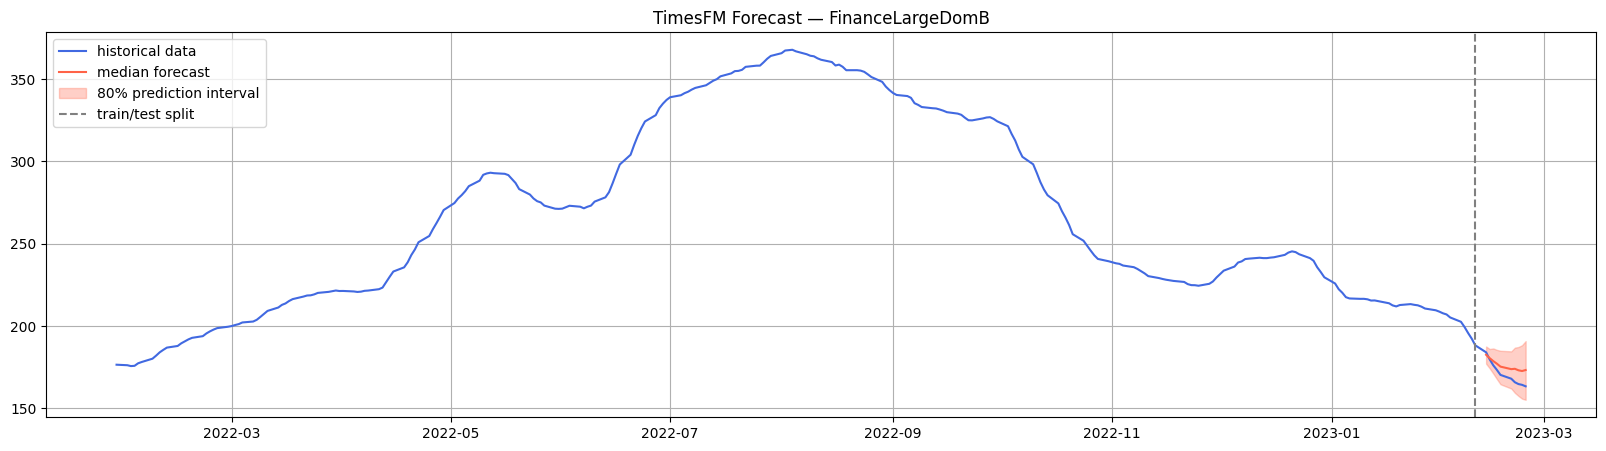

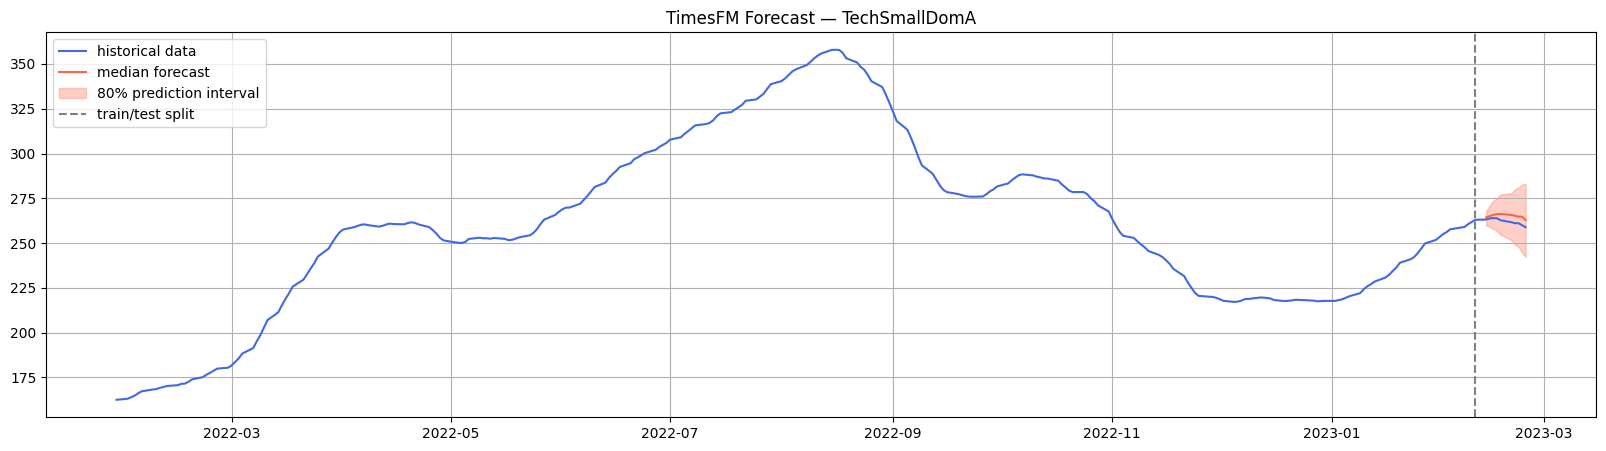

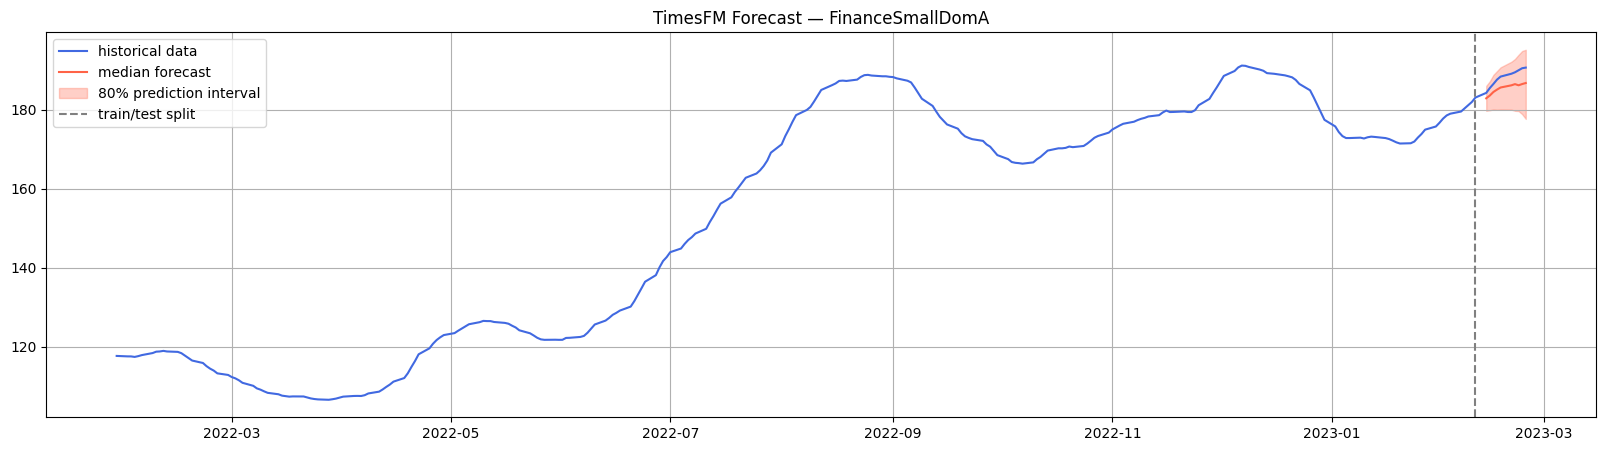

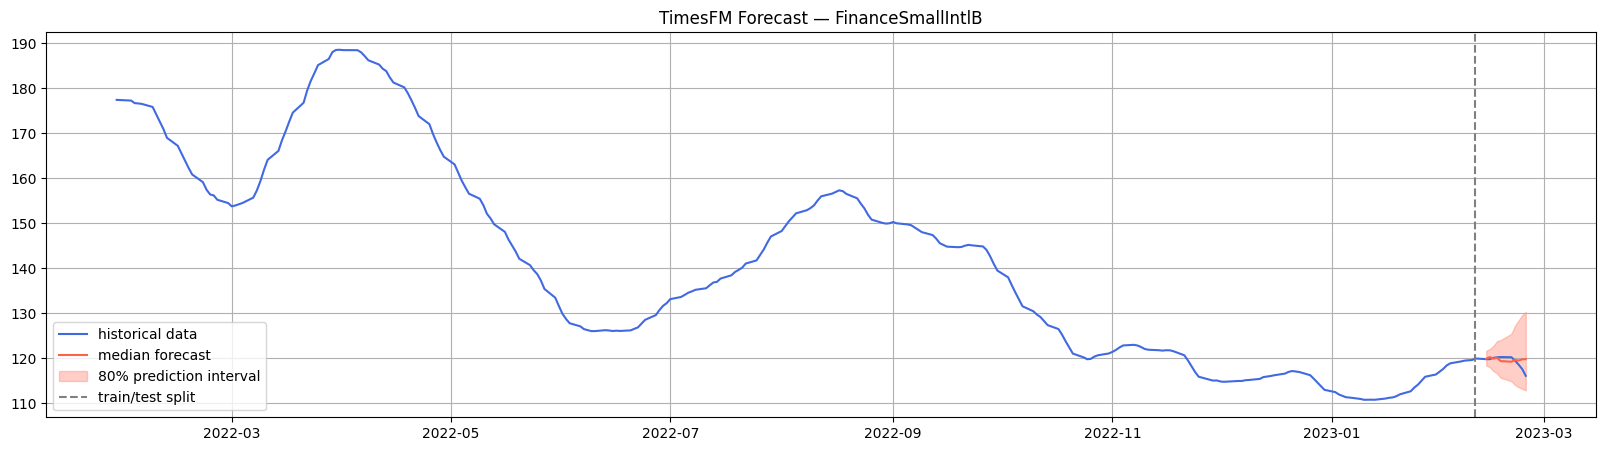

In [15]:
# Plot top 4 series by average price
top_series = (
    df.groupby('unique_id')[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

for uid in top_series:
    actuals  = df[df['unique_id'] == uid]
    forecast = forecast_df[forecast_df['unique_id'] == uid]

    plt.figure(figsize=(20, 5))
    plt.plot(actuals[TIME_COL], actuals[TARGET], color='royalblue', label='historical data')
    plt.plot(forecast[TIME_COL], forecast['forecast'], color='tomato', label='median forecast')
    plt.fill_between(
        forecast[TIME_COL],
        forecast['forecast_lower'],
        forecast['forecast_upper'],
        color='tomato', alpha=0.3, label='80% prediction interval'
    )
    plt.axvline(x=train[train['unique_id'] == uid][TIME_COL].max(), color='gray', linestyle='--', label='train/test split')
    plt.legend()
    plt.grid()
    plt.title(f"TimesFM Forecast — {uid}")
    plt.show()

# Model Evaluation

In [ ]:
import matplotlib.ticker as mtick
import seaborn as sns

# Merge actuals with forecast on test period
eval_df = pd.merge(
    test[['unique_id', TIME_COL, TARGET]],
    forecast_df[['unique_id', TIME_COL, 'forecast']],
    on=['unique_id', TIME_COL],
    how='inner'
)

eval_df['MAPE'] = (eval_df[TARGET] - eval_df['forecast']).abs() / eval_df[TARGET].abs()

# Overall MAPE per series
mape_summary = eval_df.groupby('unique_id')['MAPE'].mean().reset_index().sort_values('MAPE')
print(f"Mean MAPE across all series: {eval_df['MAPE'].mean():.2%}")
print(mape_summary.to_string(index=False))

In [ ]:
# MAPE over time
mape_by_date = eval_df.groupby(TIME_COL)['MAPE'].mean().reset_index()

plt.figure(figsize=(20, 5))
ax = sns.barplot(data=mape_by_date, x=TIME_COL, y='MAPE', color='#fa7302')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.title('TimesFM — Mean MAPE per day (test period)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()